In [1]:
%run "./02_EMS_preprocessing.ipynb"
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

def mae(y, yh): return float(np.mean(np.abs(y - yh)))
def rmse(y, yh): return float(np.sqrt(np.mean((y - yh) ** 2)))
def r2(y, yh):
    den = np.sum((y - np.mean(y)) ** 2)
    return float(1 - np.sum((y - yh) ** 2) / den) if not np.isclose(den, 0) else np.nan

train_df = pd.read_csv(PROCESSED_DIR / 'train_with_baselines.csv')
val_df = pd.read_csv(PROCESSED_DIR / 'validation_with_baselines.csv')
test_df = pd.read_csv(PROCESSED_DIR / 'test_with_baselines.csv')
print(train_df.shape, val_df.shape, test_df.shape)

ROOT_DIR  : C:\Users\Admin\Desktop\Projet_Artemis2
DATA_FILE : C:\Users\Admin\Desktop\Projet_Artemis2\data\Artemis.csv | existe: True
RANDOM_SEED: 42 | DEVICE: cuda
CONFIGURATION DU PROJET HESS

BATTERIE ÉNERGIE
Énergie          : 13709.89 Wh
Tension          : 450.00 V
Capacité         : 30.4664 Ah
Masse            : 55.12 kg
Courant recharge : -14.00 A
Courant décharge : 28.00 A
Configuration    : 125S7P

BATTERIE PUISSANCE
Énergie          : 2987.12 Wh
Tension          : 402.60 V
Capacité         : 7.4196 Ah
Masse            : 50.02 kg
Courant recharge : -130.00 A
Courant décharge : 400.00 A
Configuration    : 122S2P

HESS
Énergie totale   : 16697.01 Wh
Masse totale     : 105.14 kg
Tension du bus   : 402.60 V
Puissance min    : -58638.00 W
Puissance max    : 173640.00 W

MODÈLES
LSTM seul        : 7 → 64 → 3
LSTM NS          : 15 → 64 → 3
GNN simple       : 12 → 32 → 1
MLP simple       : 5 → 64 → 32 → 1
MLP NS           : 17 → 64 → 32 → 1

Device           : cuda
Fichier          : 

,time,speed,hasAeroForce,hasRollingForce,hasGravityForce,hasAcceleration,hasAccelerationForce,hasTotalForce,hasPower,P_EB,P_PB,P_conv,I_EB,I_PB,I_load,I_prime,SOC_EB,SOC_PB,SOC_HESS
0,1,0.0,0.0,109.87,0.0,0.0,0.0,109.87,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
1,2,0.0,0.0,109.87,0.0,0.0,0.0,109.87,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
2,3,0.0,0.0,109.87,0.0,0.0,0.0,109.87,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
3,4,0.0,0.0,109.87,0.0,0.0,0.0,109.87,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
4,5,0.0,0.0,109.87,0.0,0.0,0.0,109.87,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0


Colonnes manquantes : []
Colonnes supplémentaires : []
Valeurs manquantes : 0
Erreurs de conversion :


Series([], dtype: int64)

Valeurs infinies : 0
Lignes dupliquées : 0
Temps dupliqués : 0
Temps croissant : True
DT médian : 1.0
DT minimum : 1.0
DT maximum : 1.0
Pas de temps régulier : True
Erreur moyenne : 6.086558954327658e-15
MAE puissance  : 1.2407821959603739e-13
RMSE puissance : 4.5144916748033096e-13
Erreur maximale: 3.637978807091713e-12
Équilibre de puissance valide : True
SOC_EB violations strictes : 439
SOC_EB violations réelles  : 0
SOC_PB violations strictes : 0
SOC_PB violations réelles  : 0
SOC_EB min/max : 0.199749 1.0
SOC_PB min/max : 0.202598 1.0
SOC_EB ajustés : 439
SOC_PB ajustés : 0
Violations P_EB : 0
Violations P_PB : 0
Violations I_EB : 0
Violations I_PB : 0
Violations P_conv : 0
MAE P_EB vs V×I : 0.006657604955272979
MAE P_PB vs V×I : 0.0027196930488800094
MAE SOC_HESS : 3.0371527232069272e-06
Erreur max SOC_HESS : 0.00020621724428507293


,count,mean,std,min,25%,50%,75%,max
speed,14530.0,10.660828,8.094549,0.000000,3.055556,10.638889,17.076389,30.972222
hasAcceleration,14530.0,0.000082,0.704734,-4.080000,-0.220000,0.000000,0.280000,2.860000
hasPower,14530.0,3264.011708,10580.243967,-46000.000000,-751.550000,1053.660000,8279.350000,44230.330000
P_EB,14530.0,2715.173752,6027.407289,-6300.000000,-751.550000,466.140000,7622.510000,12600.000000
P_PB,14530.0,548.837956,6253.930256,-39700.000000,0.000000,0.000000,0.000000,43262.710000
P_conv,14530.0,285.998302,634.886901,-663.600000,-79.163250,49.100100,802.904400,1327.200000
I_EB,14530.0,6.033720,13.394238,-14.000000,-1.670100,1.035900,16.938900,28.000000
I_PB,14530.0,1.363234,15.533856,-98.609000,0.000000,0.000000,0.000000,107.458300
SOC_EB,14530.0,0.587983,0.247510,0.200000,0.364989,0.601149,0.808207,1.000000
SOC_PB,14530.0,0.770584,0.148476,0.202598,0.665434,0.778778,0.888395,1.000000


Total : 14530
Train : 7265
Validation : 3632
Test : 3633

Périodes
Train : 1 → 7265
Val   : 7266 → 10897
Test  : 10898 → 14530
Fichier complet : C:\Users\Admin\Desktop\Projet_Artemis2\data\processed\artemis_clean.csv
Train : C:\Users\Admin\Desktop\Projet_Artemis2\data\processed\train.csv
Validation : C:\Users\Admin\Desktop\Projet_Artemis2\data\processed\validation.csv
Test : C:\Users\Admin\Desktop\Projet_Artemis2\data\processed\test.csv


,Indicateur,Valeur
0,rows,14530
1,columns,28
2,missing_values,0
3,duplicate_rows,0
4,duplicate_time,0
5,dt_seconds,1.0
6,regular_time_step,True
7,power_balance_mae_w,0.0
8,power_balance_max_w,0.0
9,soc_eb_strict_violations,439


Rapport enregistré : C:\Users\Admin\Desktop\Projet_Artemis2\results\tables\data_quality_report.json
(7265, 30) (3632, 30) (3633, 30)


Vérification des colonnes

In [2]:
# === Cellule 2 : fenetres (avec metadata pour reconstruire les SOC plus tard) ===
def build_windows(data, cols, window, horizon):
    x = data[cols].to_numpy(dtype=np.float32)
    p = data["hasPower"].to_numpy(dtype=np.float32)
    soc_eb = data["SOC_EB"].to_numpy(dtype=np.float32)
    soc_pb = data["SOC_PB"].to_numpy(dtype=np.float32)
    time = data[TIME_COL].to_numpy()

    anchors = np.arange(window - 1, len(data) - horizon)
    targets = anchors + horizon

    X = np.empty((len(anchors), window, len(cols)), dtype=np.float32)
    y = np.empty((len(anchors), 3), dtype=np.float32)

    for k, anchor in enumerate(anchors):
        start = anchor - window + 1
        X[k] = x[start:anchor + 1]
        target = targets[k]
        y[k, 0] = p[target]
        y[k, 1] = soc_eb[target] - soc_eb[anchor]
        y[k, 2] = soc_pb[target] - soc_pb[anchor]

    metadata = pd.DataFrame({
        "anchor_index": anchors,
        "target_index": targets,
        "time_anchor": time[anchors],
        "time_target": time[targets],
        "SOC_EB_anchor": soc_eb[anchors],
        "SOC_PB_anchor": soc_pb[anchors],
        "SOC_EB_target": soc_eb[targets],
        "SOC_PB_target": soc_pb[targets],
    })
    return X, y, metadata


X_train, y_train, meta_train = build_windows(train_df, LSTM_INPUT_COLS, WINDOW, HORIZON)
X_val, y_val, meta_val = build_windows(val_df, LSTM_INPUT_COLS, WINDOW, HORIZON)
X_test, y_test, meta_test = build_windows(test_df, LSTM_INPUT_COLS, WINDOW, HORIZON)

print("Train      :", X_train.shape, y_train.shape)
print("Validation :", X_val.shape, y_val.shape)
print("Test       :", X_test.shape, y_test.shape)

Train      : (7241, 20, 7) (7241, 3)
Validation : (3608, 20, 7) (3608, 3)
Test       : (3609, 20, 7) (3609, 3)


Normalisation

In [3]:
# === Cellule 3 : normalisation (calculee sur les lignes du train, pas les fenetres) ===
x_train_raw = train_df[LSTM_INPUT_COLS].to_numpy(dtype=np.float32)
x_mean = x_train_raw.mean(axis=0)
x_std = x_train_raw.std(axis=0)

if np.any(x_std < 1e-12):
    constant_cols = np.array(LSTM_INPUT_COLS)[x_std < 1e-12]
    raise ValueError(f"Variables constantes dans le train : {constant_cols.tolist()}")

y_mean = y_train.mean(axis=0)
y_std = y_train.std(axis=0)

if np.any(y_std < 1e-12):
    raise ValueError("Une cible possede une variance presque nulle.")

def norm_x(X): return ((X - x_mean) / x_std).astype(np.float32)
def norm_y(y): return ((y - y_mean) / y_std).astype(np.float32)
def denorm_y(y): return y * y_std + y_mean

Xn_train, Xn_val, Xn_test = norm_x(X_train), norm_x(X_val), norm_x(X_test)
yn_train, yn_val, yn_test = norm_y(y_train), norm_y(y_val), norm_y(y_test)

LSTM_SCALER_FILE = MODELS_DIR / "EMS_LSTM_scalers.npz"
np.savez(LSTM_SCALER_FILE, x_mean=x_mean, x_std=x_std, y_mean=y_mean, y_std=y_std, input_cols=np.array(LSTM_INPUT_COLS))

print("y_mean :", y_mean)
print("y_std  :", y_std)
print("Normalisation :", LSTM_SCALER_FILE)

y_mean : [ 2.9294272e+03 -2.7507366e-04 -1.3133445e-04]
y_std  : [1.0255474e+04 4.9867423e-04 2.0269360e-03]
Normalisation : C:\Users\Admin\Desktop\Projet_Artemis2\models\EMS_LSTM_scalers.npz


Dataset et DataLoader

In [4]:
# === Cellule 4 : Dataset et DataLoader ===
class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, index): return self.X[index], self.y[index]

generator = torch.Generator()
generator.manual_seed(RANDOM_SEED)

train_loader = DataLoader(WindowDataset(Xn_train, yn_train), batch_size=LSTM_BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, generator=generator)
val_loader = DataLoader(WindowDataset(Xn_val, yn_val), batch_size=LSTM_BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(WindowDataset(Xn_test, yn_test), batch_size=LSTM_BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset))

7241 3608 3609


In [5]:
# === Cellule 5 : modele LSTM seul ===
class LSTMSeul(nn.Module):
    def __init__(self, n_features, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_size, num_layers=num_layers,
                             batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Sequential(nn.Linear(hidden_size, 32), nn.ReLU(), nn.Linear(32, 3))

    def forward(self, x):
        output, _ = self.lstm(x)
        return self.fc(output[:, -1, :])

torch.manual_seed(RANDOM_SEED)
model = LSTMSeul(n_features=len(LSTM_INPUT_COLS), hidden_size=LSTM_HIDDEN_SIZE,
                  num_layers=LSTM_NUM_LAYERS, dropout=LSTM_DROPOUT).to(DEVICE)

print(model)
print("Device du modele :", next(model.parameters()).device)

LSTMSeul(
  (lstm): LSTM(7, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=3, bias=True)
  )
)
Device du modele : cuda:0


Entrainement des modeles

In [6]:
# === Cellule 6 : entrainement ===
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LSTM_LEARNING_RATE)

best_val = float("inf")
best_epoch = -1
patience_count = 0
history = {"train": [], "val": []}

for epoch in range(LSTM_EPOCHS):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        prediction = model(xb)
        loss = criterion(prediction, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            val_loss += criterion(model(xb), yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history["train"].append(train_loss)
    history["val"].append(val_loss)

    if not np.isfinite(train_loss) or not np.isfinite(val_loss):
        raise ValueError("Loss non finie detectee.")

    if val_loss < best_val - 1e-6:
        best_val, best_epoch, patience_count = val_loss, epoch, 0
        torch.save(model.state_dict(), LSTM_BASELINE_CHECKPOINT)
    else:
        patience_count += 1

    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1:3d}/{LSTM_EPOCHS} train={train_loss:.6f} val={val_loss:.6f} patience={patience_count}")

    if patience_count >= LSTM_PATIENCE:
        print(f"Arret anticipe a l'epoque {epoch + 1}.")
        break

try:
    state_dict = torch.load(LSTM_BASELINE_CHECKPOINT, map_location=DEVICE, weights_only=True)
except TypeError:
    state_dict = torch.load(LSTM_BASELINE_CHECKPOINT, map_location=DEVICE)

model.load_state_dict(state_dict)
print("Meilleure epoque :", best_epoch + 1)
print("Meilleure val loss :", best_val)

Epoch   1/100 train=0.766392 val=0.743103 patience=0
Epoch   5/100 train=0.507135 val=0.627167 patience=1
Epoch  10/100 train=0.341269 val=0.378599 patience=0
Epoch  15/100 train=0.198563 val=0.212074 patience=0
Epoch  20/100 train=0.139059 val=0.126001 patience=0
Epoch  25/100 train=0.108117 val=0.099306 patience=0
Epoch  30/100 train=0.085242 val=0.079119 patience=0
Epoch  35/100 train=0.072550 val=0.066145 patience=1
Epoch  40/100 train=0.062695 val=0.058805 patience=3
Epoch  45/100 train=0.055515 val=0.049394 patience=4
Epoch  50/100 train=0.049441 val=0.040446 patience=0
Epoch  55/100 train=0.041787 val=0.038204 patience=2
Epoch  60/100 train=0.039950 val=0.028495 patience=1
Epoch  65/100 train=0.035407 val=0.029393 patience=2
Epoch  70/100 train=0.033325 val=0.029600 patience=2
Epoch  75/100 train=0.032129 val=0.024518 patience=3
Epoch  80/100 train=0.027212 val=0.019348 patience=0
Epoch  85/100 train=0.026751 val=0.017970 patience=0
Epoch  90/100 train=0.025172 val=0.017427 pati

Courbes d'apprentissage

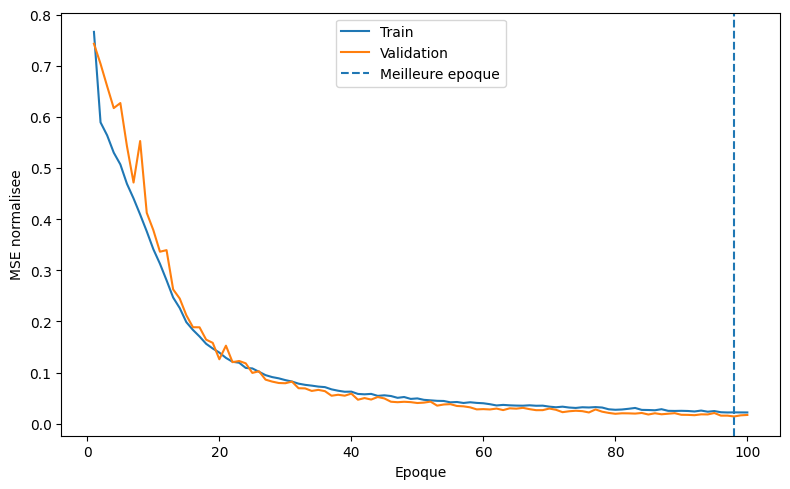

In [7]:
# === Cellule 7 : courbes d'apprentissage ===
history_df = pd.DataFrame({"epoch": np.arange(1, len(history["train"]) + 1),
                            "train_loss": history["train"], "val_loss": history["val"]})
history_df.to_csv(TABLES_DIR / "lstm_seul_training_history.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation")
plt.axvline(best_epoch + 1, linestyle="--", label="Meilleure epoque")
plt.xlabel("Epoque")
plt.ylabel("MSE normalisee")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lstm_seul_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

Evaluation sur le test

In [8]:
# === Cellule 8 : evaluation sur le test vs persistance ===
def predict(model, loader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for xb, _ in loader:
            predictions.append(model(xb.to(DEVICE, non_blocking=True)).cpu().numpy())
    return np.concatenate(predictions, axis=0)

pred_test_normalized = predict(model, test_loader)
pred_test = denorm_y(pred_test_normalized)

target_names = ["Pdem", "delta_SOC_EB", "delta_SOC_PB"]

persist_metrics = pd.read_csv(TABLES_DIR / "persistence_metrics.csv")
persist_test = persist_metrics[persist_metrics["split"] == "test"].set_index("target")

rows = []
for index, target in enumerate(target_names):
    y_true, y_pred = y_test[:, index], pred_test[:, index]
    row = {
        "target": target,
        "lstm_mae": mae(y_true, y_pred), "lstm_rmse": rmse(y_true, y_pred), "lstm_r2": r2(y_true, y_pred),
        "persistence_mae": persist_test.loc[target, "mae"],
        "persistence_rmse": persist_test.loc[target, "rmse"],
        "persistence_r2": persist_test.loc[target, "r2"],
    }
    row["mae_improvement_percent"] = 100 * (row["persistence_mae"] - row["lstm_mae"]) / row["persistence_mae"]
    rows.append(row)

comparison_df = pd.DataFrame(rows)
display(comparison_df)
comparison_df.to_csv(TABLES_DIR / "lstm_seul_vs_persistence.csv", index=False)

,target,lstm_mae,lstm_rmse,lstm_r2,persistence_mae,persistence_rmse,persistence_r2,mae_improvement_percent
0,Pdem,3506.524170,8126.951660,0.438197,8809.201186,13050.956373,-0.448818,60.194754
1,delta_SOC_EB,0.000091,0.000170,0.870454,0.000371,0.000524,-0.227789,75.382063
2,delta_SOC_PB,0.000911,0.002563,0.229330,0.001424,0.002986,-0.045978,36.028268


Prédiction par rapport aux valeurs réelles

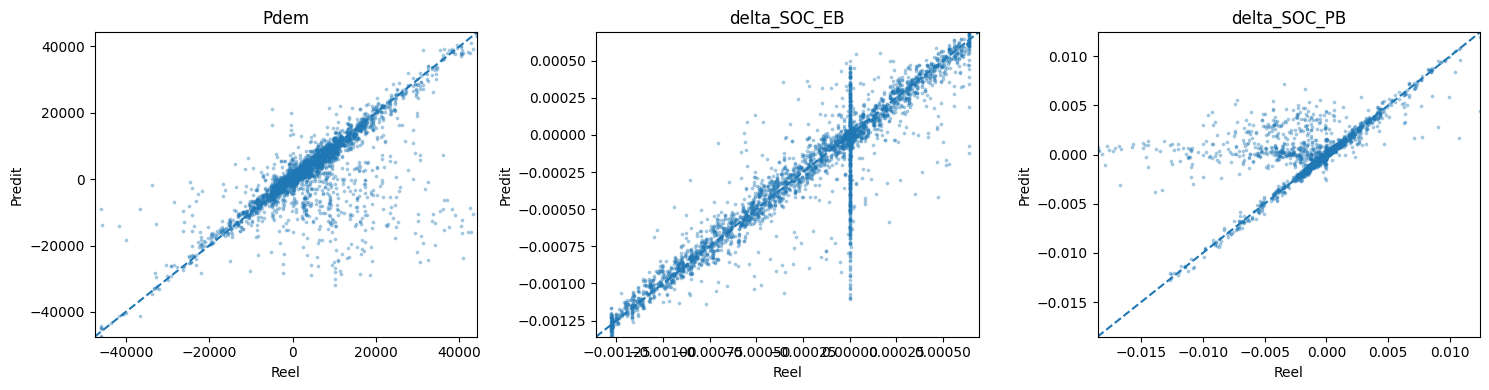

In [9]:
# === Cellule 9 : predictions vs reel ===
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for index, target in enumerate(target_names):
    y_true, y_pred = y_test[:, index], pred_test[:, index]
    lower, upper = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    axes[index].scatter(y_true, y_pred, s=3, alpha=0.3)
    axes[index].plot([lower, upper], [lower, upper], linestyle="--")
    axes[index].set_xlim(lower, upper)
    axes[index].set_ylim(lower, upper)
    axes[index].set_title(target)
    axes[index].set_xlabel("Reel")
    axes[index].set_ylabel("Predit")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lstm_seul_pred_vs_true.png", dpi=300, bbox_inches="tight")
plt.show()

Sauvegarde 

In [10]:
# === Cellule 10 : sauvegarde des predictions et verification des bornes SOC ===
pred_df = meta_test.copy()
pred_df["Pdem_true"] = y_test[:, 0]
pred_df["Pdem_pred"] = pred_test[:, 0]
pred_df["delta_SOC_EB_true"] = y_test[:, 1]
pred_df["delta_SOC_EB_pred"] = pred_test[:, 1]
pred_df["delta_SOC_PB_true"] = y_test[:, 2]
pred_df["delta_SOC_PB_pred"] = pred_test[:, 2]

pred_df["SOC_EB_pred"] = pred_df["SOC_EB_anchor"] + pred_df["delta_SOC_EB_pred"]
pred_df["SOC_PB_pred"] = pred_df["SOC_PB_anchor"] + pred_df["delta_SOC_PB_pred"]
pred_df["SOC_EB_pred_in_bounds"] = pred_df["SOC_EB_pred"].between(SOC_EB_MIN, SOC_EB_MAX)
pred_df["SOC_PB_pred_in_bounds"] = pred_df["SOC_PB_pred"].between(SOC_PB_MIN, SOC_PB_MAX)

prediction_file = PREDICTIONS_DIR / "predictions_lstm_seul.csv"
pred_df.to_csv(prediction_file, index=False)

print("Predictions :", prediction_file)
print("Checkpoint  :", LSTM_BASELINE_CHECKPOINT)
print("Normalisation :", LSTM_SCALER_FILE)
print("SOC_EB hors bornes :", int((~pred_df["SOC_EB_pred_in_bounds"]).sum()))
print("SOC_PB hors bornes :", int((~pred_df["SOC_PB_pred_in_bounds"]).sum()))

Predictions : C:\Users\Admin\Desktop\Projet_Artemis2\results\predictions\predictions_lstm_seul.csv
Checkpoint  : C:\Users\Admin\Desktop\Projet_Artemis2\models\checkpoints\EMS_LSTM.pt
Normalisation : C:\Users\Admin\Desktop\Projet_Artemis2\models\EMS_LSTM_scalers.npz
SOC_EB hors bornes : 305
SOC_PB hors bornes : 0


In [11]:
import torch, os

CKPT_DIR = r"C:\Users\Admin\Desktop\Projet_Artemis2\models\checkpoints"

targets = ["EMS_MLP.pt", "EMS_MLP_neurosymbolic.pt", "EMS_GNN.pt",
           "EMS_LSTM.pt", "EMS_LSTM_neurosymbolic.pt"]

for name in targets:
    print("=" * 50, name)
    path = os.path.join(CKPT_DIR, name)
    if not os.path.exists(path):
        print("  INTROUVABLE :", path)
        continue
    try:
        obj = torch.load(path, map_location="cpu", weights_only=False)
        if isinstance(obj, dict):
            for k, v in obj.items():
                if hasattr(v, "shape"):
                    print(f"  {k}: tensor {tuple(v.shape)}")
                elif isinstance(v, dict):
                    print(f"  {k}: dict avec clés {list(v.keys())[:10]}")
                else:
                    s = str(v)
                    print(f"  {k}: {type(v)} -> {s if len(s) < 200 else s[:200]}")
        else:
            print(f"  Objet direct de type {type(obj)}")
            if hasattr(obj, "state_dict"):
                for k, v in obj.state_dict().items():
                    print(f"    {k}: {tuple(v.shape)}")
    except Exception as e:
        print("  ERREUR :", e)

================================================== EMS_MLP.pt
  net.0.weight: tensor (64, 5)
  net.0.bias: tensor (64,)
  net.3.weight: tensor (32, 64)
  net.3.bias: tensor (32,)
  net.5.weight: tensor (1, 32)
  net.5.bias: tensor (1,)
================================================== EMS_MLP_neurosymbolic.pt
  net.0.weight: tensor (64, 17)
  net.0.bias: tensor (64,)
  net.3.weight: tensor (32, 64)
  net.3.bias: tensor (32,)
  net.5.weight: tensor (1, 32)
  net.5.bias: tensor (1,)
================================================== EMS_GNN.pt
  convs.0.bias: tensor (32,)
  convs.0.lin.weight: tensor (32, 12)
  convs.1.bias: tensor (32,)
  convs.1.lin.weight: tensor (32, 32)
  head.0.weight: tensor (16, 32)
  head.0.bias: tensor (16,)
  head.3.weight: tensor (1, 16)
  head.3.bias: tensor (1,)
================================================== EMS_LSTM.pt
  lstm.weight_ih_l0: tensor (256, 7)
  lstm.weight_hh_l0: tensor (256, 64)
  lstm.bias_ih_l0: tensor (256,)
  lstm.bias_hh_l0: tensor 